## Modelo ARIMAX para aplicación de variables exógenas

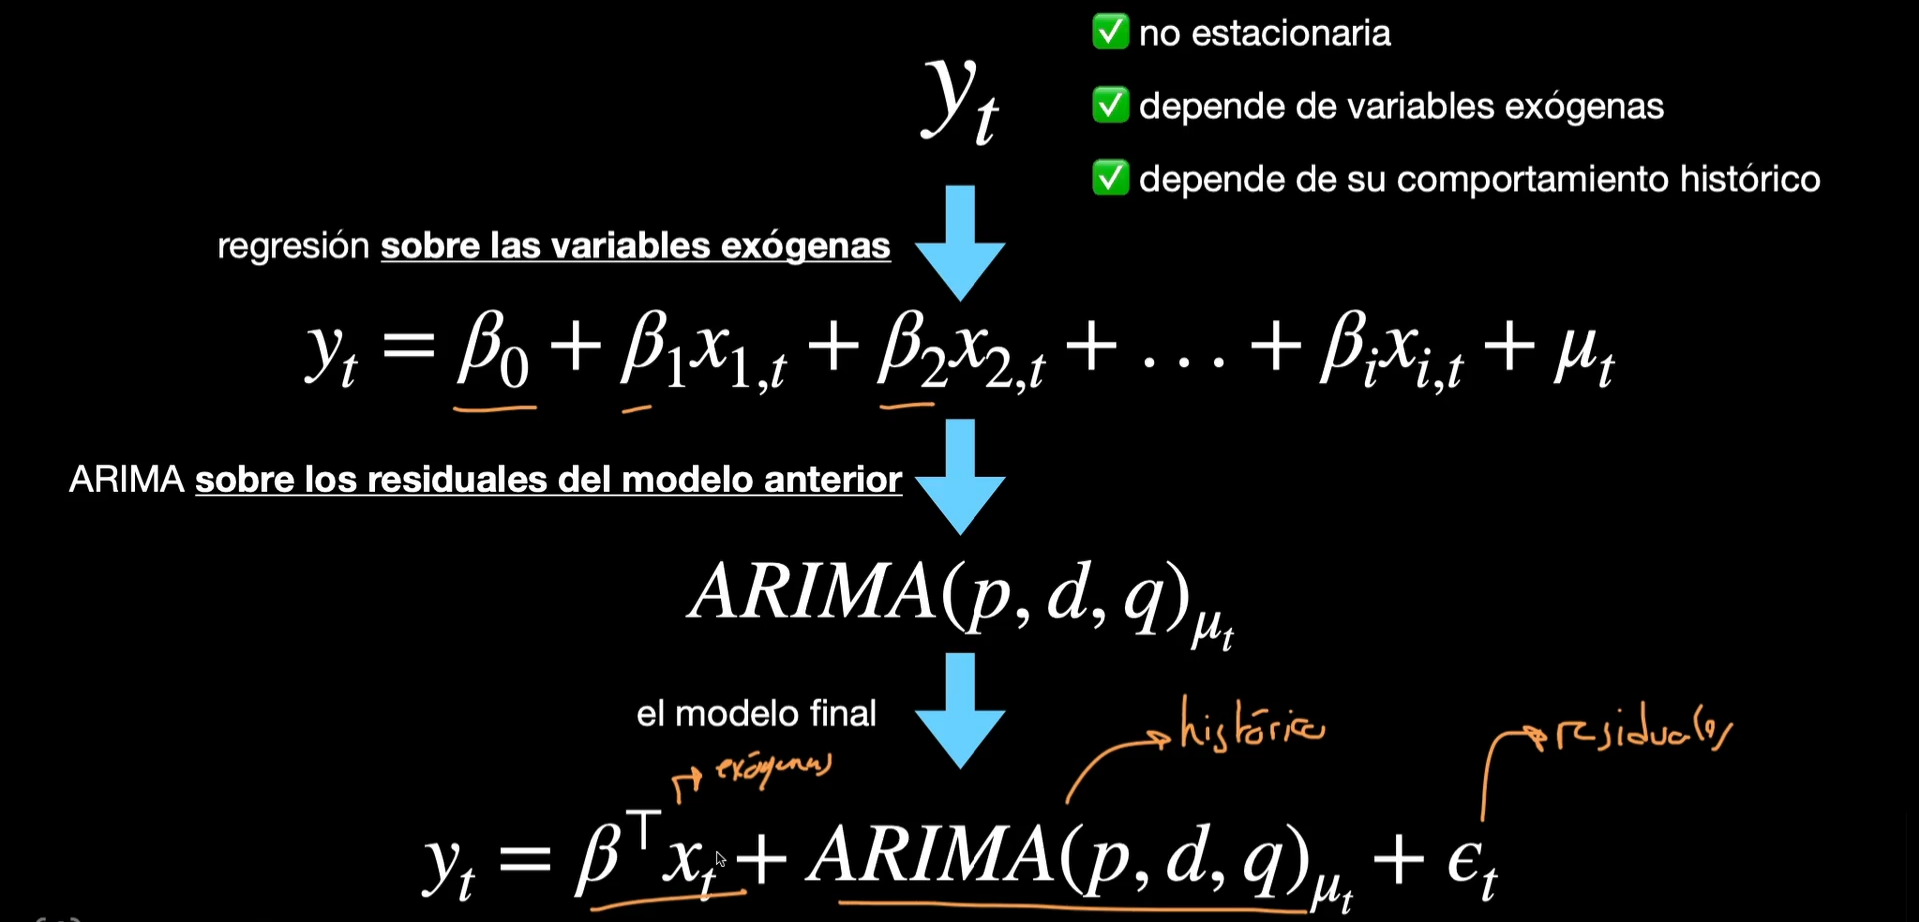

1. Primero se modela un modelo de regresión sobre las variables exógenas.
    - Se capturan las variaciónes mas significativas (**más abruptas**) relacionadas con las variables exógenas
    - NO se alcanza a capturar el comportamiento histórico de la serie
2. Los patrónes que no logra capturar el modelo, son aprendidos entonces por un modelo ARIMA
    - Se construye sobre los residuales del anterior modelo de regresión

In [3]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelo de regresión <--------
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## El set de datos y el problema a resolver

El set de datos "ventas_arimax.csv" contiene el registro histórico de ventas de una cierta categoría de productos durante el último año.

Además de esto, contamos con datos de dos variables exógenas para el mismo periodo de tiempo:
- Si hubo o no promociones (1 o 0)
- Si se trató de un evento especial o no (1 o 0)

Así que el problema a resolver será:

> Construir un modelo ARIMAX para pronosticar las ventas con un horizonte de 7 días, que incorpore no sólo el comportamiento histórico de la Serie sino también las variables exógenas

In [4]:
df = pd.read_csv('datos/ventas_arimax.csv', parse_dates=['ds'])
df

,unique_id,ds,promociones,eventos,y
0,productos_C,2025-03-01,0,0,19
1,productos_C,2025-03-02,0,0,18
2,productos_C,2025-03-03,0,0,18
3,productos_C,2025-03-04,0,0,22
4,productos_C,2025-03-05,0,0,19
...,...,...,...,...,...
360,productos_C,2026-02-24,0,0,20
361,productos_C,2026-02-25,0,0,18
362,productos_C,2026-02-26,0,0,21
363,productos_C,2026-02-27,0,1,27


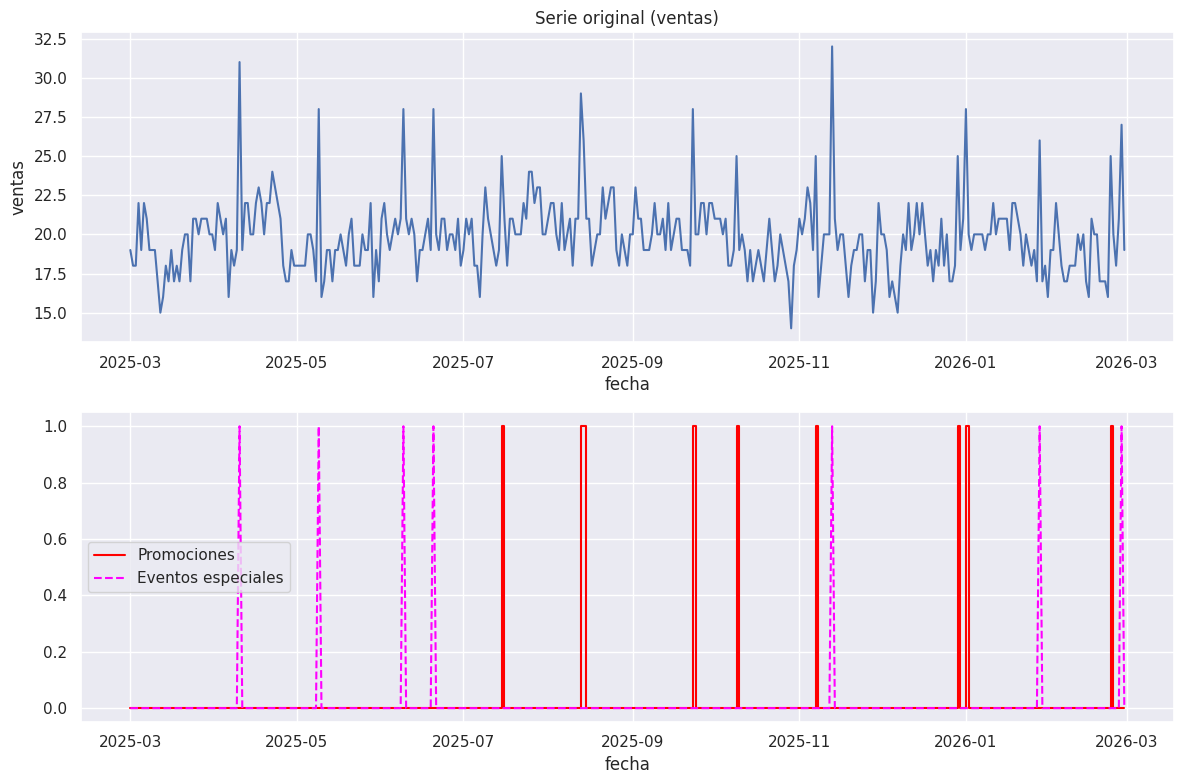

In [5]:
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (ventas)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('ventas')

# Variables exógenas
axs[1].plot(df["ds"], df["promociones"], label="Promociones", drawstyle="steps-post", color='red')
axs[1].plot(df["ds"], df["eventos"], label="Eventos especiales", linestyle="--", color='magenta')
axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();